# NB04c — Residual Diagnostics for the Numerical Models

The leaderboards in NB04 and NB04b rank models by a single number. This notebook
asks a different question: **when a model is wrong, how is it wrong?**

It reads cached backtest results **from disk**. It never refits a model and
never calls an LLM, so it is free to re-run and safe to iterate on.

Scope is the numerical models — ARIMA, Kalman, LightGBM, ECM, and the Naive
baseline. The LLM and agent predictors are excluded on purpose: their residuals
are worth studying, but they mix a numerical baseline with a text-conditioned
adjustment, and the two need separating before the residual means anything.

**Sections**

1. Load cached results
2. **Origin-grid audit** — do all predictors answer the same questions?
3. Residual frame
4. Bias and dispersion
5. Residuals through time
6. Calibration across every quantile level
7. Residual persistence
8. Error against volatility regime
9. Paired comparison against Naive

## 1. Load cached results

Point `SPEC_ID` at whichever backtest you want to dissect. The store layout is
`data/predictions/<spec_id>/<predictor_id>__<task_id>.yaml`, written by
`cached_multi_backtest`.

Nothing here runs a model. If a file is missing, its predictor is simply absent
from the tables below.

In [1]:
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from aieng.forecasting.evaluation.backtest import BacktestResult
from energy_oil_forecasting.data import build_wti_multivariate_service

warnings.filterwarnings("ignore")

# ── What to dissect ──────────────────────────────────────────────────────────
SPEC_ID = "energy_oil_backtest_10yr_quarterly"
STORE = Path("data/predictions")

# Numerical predictors only. Substring match against the cached predictor_id,
# so a new numerical model is added by appending one entry here.
NUMERICAL_PATTERNS = (
    "last_value_naive",
    "darts_autoarima",
    "kalman",
    "darts_lightgbm",
    "ecm",
)

# Optional prettifying: cached predictor_id → display name.
NAME_MAP: dict[str, str] = {}


def load_cached_results(spec_id: str, store: Path = STORE) -> dict[str, dict[str, BacktestResult]]:
    """Load every cached BacktestResult for a spec into notebook shape.

    Returns ``{display_name: {task_id: BacktestResult}}`` — the same structure
    the notebooks hold in ``backtest_results``, so every helper in
    ``analysis.py`` accepts it unchanged.
    """
    spec_dir = store / spec_id
    if not spec_dir.is_dir():
        raise FileNotFoundError(
            f"No cache at {spec_dir}. Check SPEC_ID, and check you are running "
            f"from the energy_oil_forecasting directory (cwd={Path.cwd()})."
        )

    out: dict[str, dict[str, BacktestResult]] = {}
    for path in sorted(spec_dir.glob("*.yaml")):
        stem = path.stem
        if "__" not in stem:
            continue
        predictor_id, task_id = stem.split("__", 1)
        if not any(p in predictor_id.lower() for p in NUMERICAL_PATTERNS):
            continue
        result = BacktestResult.model_validate(yaml.safe_load(path.read_text()))
        name = NAME_MAP.get(predictor_id, predictor_id)
        out.setdefault(name, {})[task_id] = result
    return out


results = load_cached_results(SPEC_ID)
data_service = build_wti_multivariate_service()

print(f"Loaded {len(results)} numerical predictor(s) from {STORE / SPEC_ID}\n")
for name, by_task in results.items():
    for r in by_task.values():
        print(f"  {name:<44} n_pred={len(r.predictions):<5} horizons={r.spec.task.horizons}")

Loaded 10 numerical predictor(s) from data/predictions/energy_oil_backtest_10yr_quarterly

  darts_autoarima                              n_pred=165   horizons=[5, 10, 21, 63]
  darts_kalman                                 n_pred=165   horizons=[5, 10, 21, 63]
  darts_lightgbm_cov                           n_pred=165   horizons=[5, 10, 21, 63]
  darts_lightgbm_cov_expanded                  n_pred=165   horizons=[5, 10, 21, 63]
  ecm_regression                               n_pred=167   horizons=[5, 10, 21, 63]
  ecm_regression_expanded                      n_pred=167   horizons=[5, 10, 21, 63]
  ecm_regression_expanded_levelonly            n_pred=167   horizons=[5, 10, 21, 63]
  ecm_regression_expanded_levelonly_yields     n_pred=167   horizons=[5, 10, 21, 63]
  ecm_regression_expanded_yields               n_pred=167   horizons=[5, 10, 21, 63]
  last_value_naive                             n_pred=165   horizons=[5, 10, 21, 63]


## 2. Origin-grid audit

**Run this before reading any comparison below.**

Every predictor receives the same spec, so every predictor should forecast from
the same origin dates. When one does not, its errors are measured against
different realised prices than its neighbours' and the leaderboard silently
stops being a like-for-like comparison.

This is not hypothetical — an ECM variant in this project sat on a grid shifted
+3 business days from every other model, with the expanded-covariate variant
shifted +4. The offset was constant across a ten-year window, which is the
signature of the origin being taken from the model's own design matrix rather
than from the harness.

The table flags any predictor whose origin set differs from the majority grid.

In [2]:
def origin_grid_audit(results: dict[str, dict[str, BacktestResult]]) -> pd.DataFrame:
    """Compare every predictor's origin set against the majority grid."""
    grids = {
        name: frozenset(pd.Timestamp(p.as_of).normalize() for r in by_task.values() for p in r.predictions)
        for name, by_task in results.items()
    }
    if not grids:
        return pd.DataFrame()

    # The majority grid is the one the most predictors agree on.
    counts: dict[frozenset, int] = {}
    for g in grids.values():
        counts[g] = counts.get(g, 0) + 1
    reference = max(counts, key=lambda g: counts[g])
    ref_sorted = sorted(reference)

    rows = []
    for name, grid in grids.items():
        g_sorted = sorted(grid)
        # Median business-day offset against the reference, matched by rank.
        if len(g_sorted) == len(ref_sorted):
            offsets = [
                (len(pd.bdate_range(min(a, b), max(a, b))) - 1) * (1 if b > a else -1)
                for a, b in zip(ref_sorted, g_sorted, strict=True)
            ]
            offset = int(np.median(offsets)) if offsets else 0
            constant = len(set(offsets)) == 1
        else:
            offset, constant = np.nan, False
        rows.append(
            {
                "Predictor": name,
                "n_origins": len(grid),
                "first": g_sorted[0].date() if g_sorted else None,
                "last": g_sorted[-1].date() if g_sorted else None,
                "shared_with_ref": len(grid & reference),
                "offset_bd": offset,
                "constant_offset": constant,
                "on_reference_grid": grid == reference,
            }
        )
    return pd.DataFrame(rows).set_index("Predictor").sort_values("on_reference_grid", ascending=False)


audit = origin_grid_audit(results)
print("━" * 78)
print("ORIGIN-GRID AUDIT")
print("━" * 78)
print(audit.to_string())

_off = audit[~audit["on_reference_grid"]]
if _off.empty:
    print("\n✅ All predictors share one origin grid — comparisons below are like-for-like.")
else:
    print(f"\n⚠️  {len(_off)} predictor(s) are OFF the reference grid: {', '.join(_off.index)}")
    print("   Their errors are measured against different realised prices.")
    print("   A constant non-zero offset_bd points at as_of being read from the")
    print("   model's own (lag-trimmed) index instead of the harness origin.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ORIGIN-GRID AUDIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                          n_origins       first        last  shared_with_ref  offset_bd  constant_offset  on_reference_grid
Predictor                                                                                                                                  
darts_autoarima                                  43  2014-04-21  2024-06-11               43          0             True               True
darts_kalman                                     43  2014-04-21  2024-06-11               43          0             True               True
darts_lightgbm_cov                               43  2014-04-21  2024-06-11               43          0             True               True
darts_lightgbm_cov_expanded                      43  2014-04-21  2024-06-11               43          0             True    

### 2b. Horizon arithmetic

A shifted grid has two possible causes with very different consequences:

- **Mislabel** — the model used the data it was given but wrote the wrong
  `as_of` onto the `Prediction`. Results are honest, dates are wrong.
- **Leak** — the model actually fitted on data past the cutoff. Results are
  inflated.

They are distinguishable. If `forecast_date − as_of` still equals the declared
horizon, the whole problem shifted together. If it does not, the `as_of` label
is wrong while the forecast dates stayed put, and the scored horizon is not the
horizon the row is filed under.

In [3]:
def horizon_arithmetic(results: dict[str, dict[str, BacktestResult]]) -> pd.DataFrame:
    """Check that forecast_date − as_of matches a declared horizon."""
    rows = []
    for name, by_task in results.items():
        for r in by_task.values():
            declared = set(r.spec.task.horizons)
            gaps: dict[int, int] = {}
            for p in r.predictions:
                a = pd.Timestamp(p.as_of).normalize()
                f = pd.Timestamp(p.forecast_date).normalize()
                gap = max(len(pd.bdate_range(a, f)) - 1, 0)
                gaps[gap] = gaps.get(gap, 0) + 1
            rows.append(
                {
                    "Predictor": name,
                    "declared_horizons": sorted(declared),
                    "observed_gaps": dict(sorted(gaps.items())),
                    "all_match": set(gaps) <= declared,
                }
            )
    return pd.DataFrame(rows).set_index("Predictor")


print(horizon_arithmetic(results).to_string())

                                         declared_horizons                    observed_gaps  all_match
Predictor                                                                                             
darts_autoarima                            [5, 10, 21, 63]  {5: 41, 10: 41, 21: 42, 63: 41}       True
darts_kalman                               [5, 10, 21, 63]  {5: 41, 10: 41, 21: 42, 63: 41}       True
darts_lightgbm_cov                         [5, 10, 21, 63]  {5: 41, 10: 41, 21: 42, 63: 41}       True
darts_lightgbm_cov_expanded                [5, 10, 21, 63]  {5: 41, 10: 41, 21: 42, 63: 41}       True
ecm_regression                             [5, 10, 21, 63]  {5: 40, 10: 43, 21: 42, 63: 42}       True
ecm_regression_expanded                    [5, 10, 21, 63]  {5: 40, 10: 43, 21: 42, 63: 42}       True
ecm_regression_expanded_levelonly          [5, 10, 21, 63]  {5: 43, 10: 40, 21: 42, 63: 42}       True
ecm_regression_expanded_levelonly_yields   [5, 10, 21, 63]  {5: 43, 10: 4

## 3. Residual frame

One row per scored prediction. `residual = actual − point_forecast`, so a
**positive residual means the model forecast too low**.

`predictions_to_frame` supplies the columns; `resid` is `signed_error` under a
name that says what it is.

In [4]:
from energy_oil_forecasting.analysis import predictions_to_frame

frame = predictions_to_frame(results, data_service)
frame = frame.dropna(subset=["actual"]).copy()
frame["resid"] = frame["signed_error"]
frame["origin"] = pd.to_datetime(frame["as_of"]).dt.normalize()
frame["year"] = frame["origin"].dt.year

HORIZONS = sorted(frame["horizon"].unique())
PREDICTORS = sorted(frame["predictor"].unique())

print(f"{len(frame):,} scored predictions | {frame['origin'].nunique()} origins "
      f"| horizons {HORIZONS}")
print(f"window {frame['origin'].min().date()} → {frame['origin'].max().date()}\n")
print(frame.groupby(["predictor", "horizon"]).size().unstack(fill_value=0).to_string())

1,660 scored predictions | 129 origins | horizons [np.int64(5), np.int64(10), np.int64(21), np.int64(63)]
window 2014-04-21 → 2024-06-17

horizon                                   5   10  21  63
predictor                                               
darts_autoarima                           41  41  42  41
darts_kalman                              41  41  42  41
darts_lightgbm_cov                        41  41  42  41
darts_lightgbm_cov_expanded               41  41  42  41
ecm_regression                            40  43  42  42
ecm_regression_expanded                   40  43  42  42
ecm_regression_expanded_levelonly         43  40  42  42
ecm_regression_expanded_levelonly_yields  43  40  42  42
ecm_regression_expanded_yields            43  40  42  42
last_value_naive                          41  41  42  41


## 4. Bias and dispersion

Four things the leaderboard hides:

- **mean** — systematic bias. A CRPS-competitive model with a large mean
  residual is being carried by its spread, not its centre.
- **std** — dispersion of the error.
- **skew** — asymmetry. Oil sells off slowly and spikes fast, so a model that
  never anticipates spikes shows positive residual skew.
- **kurtosis** — tail weight. High excess kurtosis means the occasional
  enormous miss, which is exactly what an interval built on a Gaussian
  assumption will not cover.

`t_bias` is `mean / (std/√n)`. Beyond roughly ±2 the bias is unlikely to be
sampling noise.

In [5]:
from scipy import stats


def bias_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (name, h), g in frame.groupby(["predictor", "horizon"]):
        r = g["resid"].to_numpy()
        n = len(r)
        se = r.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
        rows.append(
            {
                "Predictor": name,
                "h": h,
                "n": n,
                "mean": r.mean(),
                "std": r.std(ddof=1) if n > 1 else np.nan,
                "skew": stats.skew(r) if n > 2 else np.nan,
                "kurt": stats.kurtosis(r) if n > 3 else np.nan,
                "MAE": np.abs(r).mean(),
                "t_bias": r.mean() / se if se and se > 0 else np.nan,
            }
        )
    return pd.DataFrame(rows).set_index(["Predictor", "h"]).sort_index()


bias = bias_table(frame)
print("━" * 78)
print("RESIDUAL MOMENTS  (residual = actual − forecast; positive ⇒ forecast too low)")
print("━" * 78)
print(bias.round(3).to_string())

_biased = bias[bias["t_bias"].abs() > 2]
if not _biased.empty:
    print("\n⚠️  Systematic bias (|t| > 2):")
    for (name, h), row in _biased.iterrows():
        direction = "LOW" if row["mean"] > 0 else "HIGH"
        print(f"   {name:<40} h={h:<3} forecasts too {direction} by {abs(row['mean']):.2f} on average")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESIDUAL MOMENTS  (residual = actual − forecast; positive ⇒ forecast too low)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                              n   mean     std   skew   kurt     MAE  t_bias
Predictor                                h                                                  
darts_autoarima                          5   41  0.587   3.428  1.008  1.819   2.493   1.096
                                         10  41  0.882   4.275  0.248  0.130   3.323   1.321
                                         21  42  1.493   6.083 -0.042  0.294   4.912   1.590
                                         63  41 -1.254  12.145 -0.663  0.994   8.835  -0.661
darts_kalman                             5   41  0.631   3.448  0.875  1.324   2.538   1.172
                                         10  41  0.930   4.198  0.215  0.100   3.309   1.418
                    

## 5. Residuals through time

Bias averaged over ten years can be zero while the model is badly wrong in
every individual regime — too low through a rally, too high through a selloff.
Plotting the residual against its origin separates a genuinely unbiased model
from one whose errors merely cancel.

The shaded band is ±1 standard deviation of that predictor's residuals at that
horizon.

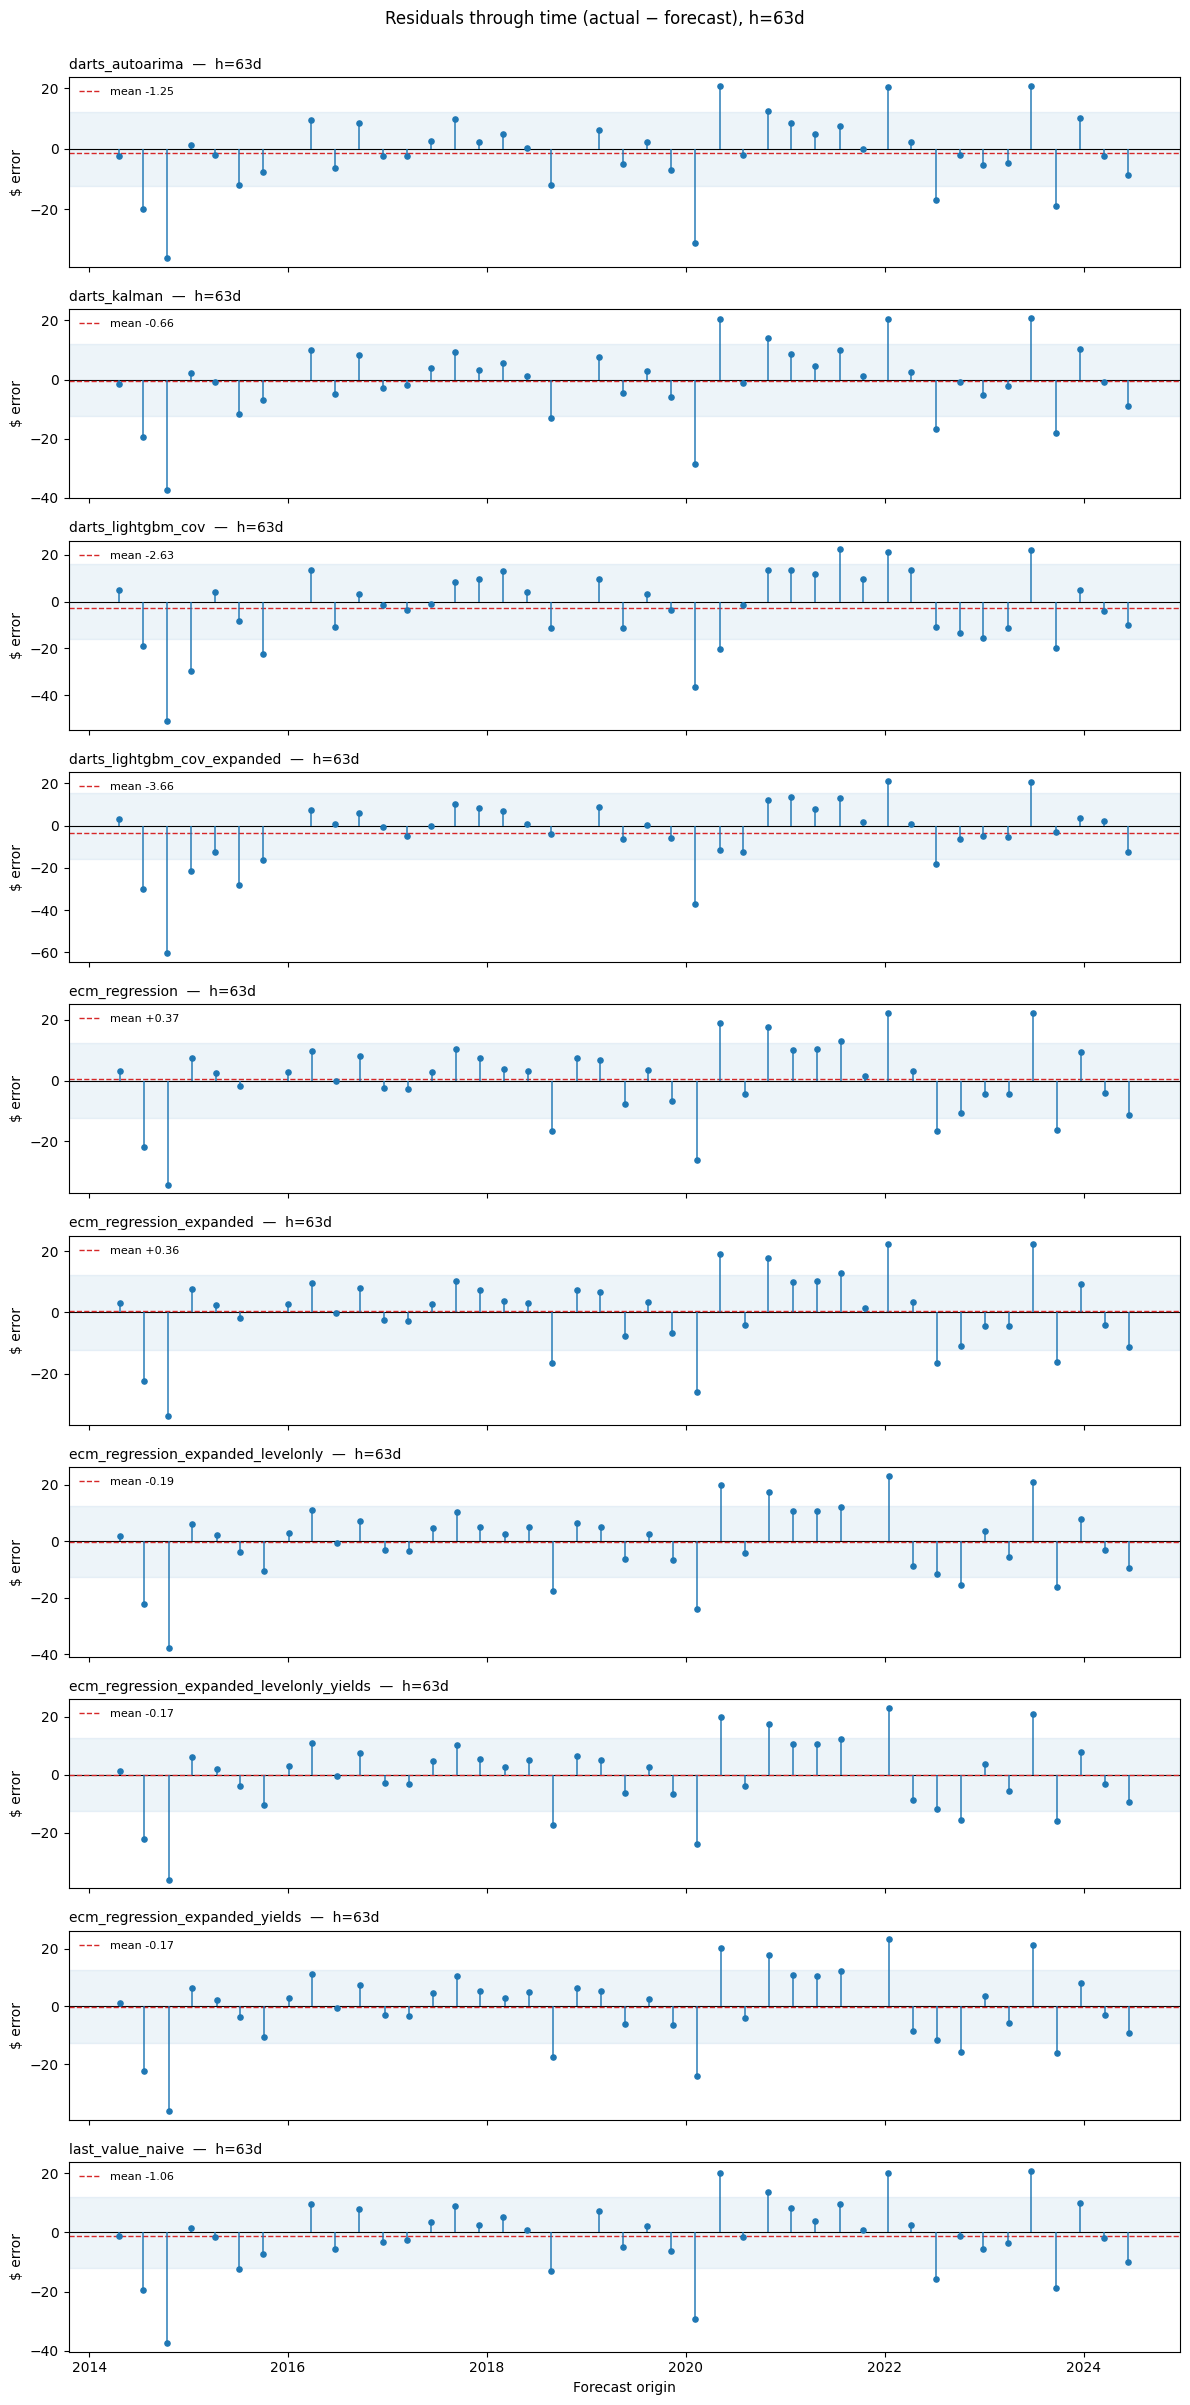

In [6]:
import matplotlib.pyplot as plt

H_PLOT = max(HORIZONS)  # the horizon where models diverge most

fig, axes = plt.subplots(len(PREDICTORS), 1, figsize=(12, 2.4 * len(PREDICTORS)), sharex=True)
axes = np.atleast_1d(axes)

for ax, name in zip(axes, PREDICTORS, strict=False):
    g = frame[(frame["predictor"] == name) & (frame["horizon"] == H_PLOT)].sort_values("origin")
    if g.empty:
        ax.set_visible(False)
        continue
    sd = g["resid"].std(ddof=1)
    ax.axhspan(-sd, sd, color="tab:blue", alpha=0.08)
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(g["resid"].mean(), color="tab:red", lw=1.0, ls="--",
               label=f"mean {g['resid'].mean():+.2f}")
    ax.vlines(g["origin"], 0, g["resid"], color="tab:blue", lw=1.4, alpha=0.75)
    ax.scatter(g["origin"], g["resid"], s=14, color="tab:blue", zorder=3)
    ax.set_ylabel("$ error")
    ax.set_title(f"{name}  —  h={H_PLOT}d", loc="left", fontsize=10)
    ax.legend(loc="upper left", fontsize=8, frameon=False)

axes[-1].set_xlabel("Forecast origin")
fig.suptitle(f"Residuals through time (actual − forecast), h={H_PLOT}d", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()

In [7]:
# Same information as a per-year bias grid — easier to compare across models.
pivot = (
    frame[frame["horizon"] == H_PLOT]
    .pivot_table(index="year", columns="predictor", values="resid", aggfunc="mean")
    .round(2)
)
print(f"Mean residual by year, h={H_PLOT}d  (positive ⇒ forecast too low)")
print(pivot.to_string())

Mean residual by year, h=63d  (positive ⇒ forecast too low)
predictor  darts_autoarima  darts_kalman  darts_lightgbm_cov  darts_lightgbm_cov_expanded  ecm_regression  ecm_regression_expanded  ecm_regression_expanded_levelonly  ecm_regression_expanded_levelonly_yields  ecm_regression_expanded_yields  last_value_naive
year                                                                                                                                                                                                                                                             
2014                -19.44        -19.52              -21.63                       -29.09          -17.61                   -17.80                             -19.46                                    -19.15                          -19.19            -19.28
2015                 -5.08         -4.39              -14.14                       -19.39            2.71                     2.71                              -1.47 

## 6. Calibration across every quantile level

A single interval hides most of what there is to know, and inviting a reader to
compare one observed number against one nominal number is how a P20–P80 band
spent this project mislabelled as "80% coverage".

Two views instead:

**Reliability.** For each emitted quantile level τ, the fraction of outcomes
falling at or below that quantile should be τ. Plotting observed against
nominal shows *where* a distribution is wrong, not just that it is.

**Central intervals.** Coverage of every symmetric band the quantile grid
supports, each against its own nominal level. A model can be honest at 50% and
badly overconfident at 90%.

In [8]:
QUANTILE_LEVELS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
BANDS = [(0.05, 0.95, 90), (0.1, 0.9, 80), (0.2, 0.8, 60), (0.3, 0.7, 40), (0.4, 0.6, 20)]


def _q(results, level):
    """Pull one quantile level for every scored prediction, aligned to `frame`."""
    from energy_oil_forecasting.analysis import _qval

    vals = []
    for name, by_task in results.items():
        for r in by_task.values():
            for p in r.predictions:
                vals.append(
                    {
                        "predictor": name,
                        "as_of": pd.Timestamp(p.as_of),
                        "forecast_date": pd.Timestamp(p.forecast_date).normalize(),
                        f"q{level}": _qval(p.payload.quantiles, level),
                    }
                )
    return pd.DataFrame(vals)


quant = frame[["predictor", "as_of", "forecast_date", "horizon", "actual"]].copy()
for lvl in QUANTILE_LEVELS:
    quant = quant.merge(_q(results, lvl), on=["predictor", "as_of", "forecast_date"], how="left")

reliability = pd.DataFrame(
    {
        f"{lvl:.2f}": quant.groupby("predictor").apply(
            lambda g, c=f"q{lvl}": float((g["actual"] <= g[c]).mean()), include_groups=False
        )
        for lvl in QUANTILE_LEVELS
    }
)
print("━" * 78)
print("RELIABILITY — P(actual ≤ quantile). Each column should equal its header.")
print("━" * 78)
print(reliability.round(3).to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RELIABILITY — P(actual ≤ quantile). Each column should equal its header.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                           0.05   0.10   0.20   0.30   0.40   0.50   0.60   0.70   0.80   0.90   0.95
predictor                                                                                                            
darts_autoarima                           0.012  0.048  0.133  0.212  0.267  0.436  0.588  0.739  0.867  0.939  0.970
darts_kalman                              0.236  0.261  0.297  0.345  0.388  0.412  0.436  0.479  0.552  0.618  0.685
darts_lightgbm_cov                        0.176  0.236  0.309  0.370  0.406  0.455  0.491  0.564  0.679  0.806  0.885
darts_lightgbm_cov_expanded               0.224  0.267  0.333  0.376  0.436  0.461  0.515  0.612  0.703  0.830  0.909
ecm_regression                            0.024  0.036  0.114

In [9]:
rows = []
for name, g in quant.groupby("predictor"):
    row = {"Predictor": name}
    for lo, hi, nominal in BANDS:
        inside = ((g[f"q{lo}"] <= g["actual"]) & (g["actual"] <= g[f"q{hi}"])).mean() * 100
        row[f"{nominal}%"] = inside
    row["n"] = len(g)
    rows.append(row)

central = pd.DataFrame(rows).set_index("Predictor")
print("━" * 78)
print("CENTRAL-INTERVAL COVERAGE — compare each column against its own header")
print("━" * 78)
print(central.round(1).to_string())

print("\nDeviation from nominal (negative ⇒ too narrow / overconfident):")
dev = central[[f"{n}%" for _, _, n in BANDS]] - [n for _, _, n in BANDS]
print(dev.round(1).to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CENTRAL-INTERVAL COVERAGE — compare each column against its own header
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                           90%   80%   60%   40%   20%    n
Predictor                                                                  
darts_autoarima                           95.8  89.1  73.3  52.7  32.1  165
darts_kalman                              44.8  35.8  25.5  13.3   4.8  165
darts_lightgbm_cov                        70.9  57.0  37.0  19.4   8.5  165
darts_lightgbm_cov_expanded               68.5  56.4  37.0  23.6   7.9  165
ecm_regression                            97.6  92.8  75.4  56.3  26.3  167
ecm_regression_expanded                   97.0  92.8  74.3  55.1  25.7  167
ecm_regression_expanded_levelonly         97.6  92.2  77.2  55.7  25.1  167
ecm_regression_expanded_levelonly_yields  97.6  92.2  77.2  55.7  25.1  167
ecm_regress

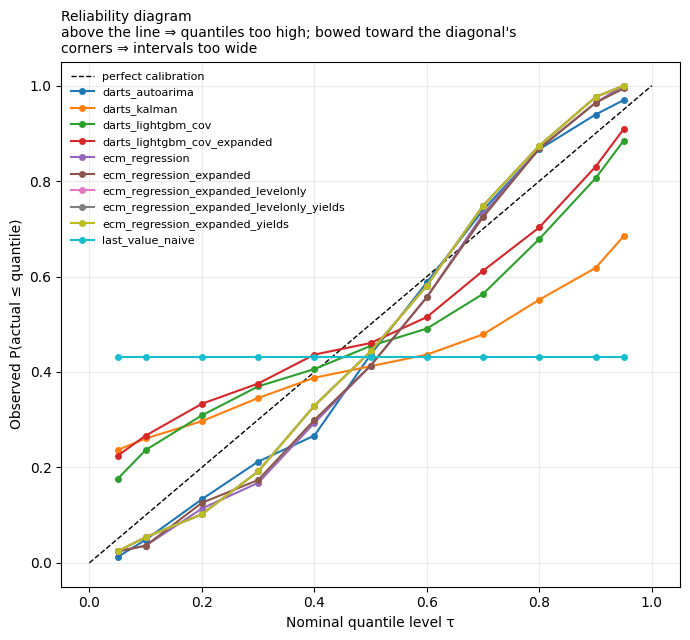

In [10]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot([0, 1], [0, 1], color="black", ls="--", lw=1, label="perfect calibration")
for name in reliability.index:
    ax.plot(
        [float(c) for c in reliability.columns],
        reliability.loc[name].to_numpy(),
        marker="o", ms=4, lw=1.5, label=name,
    )
ax.set_xlabel("Nominal quantile level τ")
ax.set_ylabel("Observed P(actual ≤ quantile)")
ax.set_title("Reliability diagram\nabove the line ⇒ quantiles too high; bowed toward the diagonal's\n"
             "corners ⇒ intervals too wide", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Residual persistence

If today's error predicts the next origin's error, the model is systematically
lagging the series and the residual still contains signal it failed to use.
That is the single clearest sign that a model can be improved without adding
any new data.

Lag-1 autocorrelation is computed per horizon over consecutive origins. With a
quarterly stride the 5-, 10- and 21-day windows do not overlap, so a non-zero
value is a property of the model rather than of overlapping targets. At the
longest horizon consecutive windows are adjacent, so read that row more
cautiously.

In [11]:
def residual_autocorr(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (name, h), g in frame.groupby(["predictor", "horizon"]):
        r = g.sort_values("origin")["resid"].to_numpy()
        if len(r) < 4:
            rows.append({"Predictor": name, "h": h, "lag1": np.nan, "n": len(r)})
            continue
        a, b = r[:-1], r[1:]
        denom = a.std() * b.std()
        rho = float(np.mean((a - a.mean()) * (b - b.mean())) / denom) if denom > 0 else np.nan
        # ±2/√n is the rough 95% band for white noise
        rows.append(
            {
                "Predictor": name,
                "h": h,
                "lag1": rho,
                "n": len(r),
                "signif": abs(rho) > 2 / np.sqrt(len(r)) if not np.isnan(rho) else False,
            }
        )
    return pd.DataFrame(rows).set_index(["Predictor", "h"]).sort_index()


ac = residual_autocorr(frame)
print("━" * 78)
print("RESIDUAL LAG-1 AUTOCORRELATION  (signif ⇒ |ρ| > 2/√n)")
print("━" * 78)
print(ac.round(3).to_string())

_persist = ac[ac["signif"].fillna(False)]
if not _persist.empty:
    print("\n⚠️  Residuals carry unexploited structure at:")
    for (name, h), row in _persist.iterrows():
        print(f"   {name:<40} h={h:<3} ρ={row['lag1']:+.2f}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESIDUAL LAG-1 AUTOCORRELATION  (signif ⇒ |ρ| > 2/√n)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                              lag1   n  signif
Predictor                                h                    
darts_autoarima                          5  -0.396  41    True
                                         10  0.214  41   False
                                         21 -0.147  42   False
                                         63 -0.072  41   False
darts_kalman                             5  -0.431  41    True
                                         10  0.167  41   False
                                         21 -0.184  42   False
                                         63 -0.053  41   False
darts_lightgbm_cov                       5  -0.206  41   False
                                         10  0.100  41   False
                                

## 8. Error against volatility regime

Aggregate error is an average over calm and turbulent markets. What matters for
an oil desk is whether a model degrades gracefully or falls apart exactly when
the price starts moving.

Origins are bucketed into terciles of trailing 21-day realised volatility,
measured strictly from data available at the origin.

In [12]:
from energy_oil_forecasting.data import WTI_SERIES_ID

prices = data_service.get_series(WTI_SERIES_ID, as_of=datetime.now()).sort_values("timestamp")
prices["timestamp"] = pd.to_datetime(prices["timestamp"]).dt.normalize()
prices = prices.set_index("timestamp")["value"]

# Trailing 21-day realised vol of log returns, annualised. Shifted by one so the
# value at an origin uses only observations strictly before it.
logret = np.log(prices).diff()
realised_vol = logret.rolling(21).std().shift(1) * np.sqrt(252) * 100

vol_at_origin = frame["origin"].map(realised_vol.reindex(frame["origin"].unique()).to_dict())
frame["vol"] = vol_at_origin.to_numpy()

_valid = frame["vol"].notna()
_n_unique = frame.loc[_valid, "vol"].nunique()

if _n_unique < 3:
    # A short window (e.g. a 2-origin smoke run) doesn't have three distinct
    # volatility readings to form terciles from. Degrade instead of crashing —
    # this table is only meaningful over a long window in any case.
    print(f"Only {_n_unique} distinct origin(s) worth of volatility — need at "
          "least 3 for terciles. Skipping regime table (this is expected on a "
          "short/smoke run; use the full backtest window for this section).")
else:
    labels = ["calm", "normal", "turbulent"]
    frame.loc[_valid, "vol_bucket"] = pd.qcut(
        frame.loc[_valid, "vol"], 3, labels=labels, duplicates="drop"
    )
    _got = frame.loc[_valid, "vol_bucket"].dropna().unique()
    if len(_got) < 3:
        print(f"Volatility values collapsed to {len(_got)} bucket(s) after "
              "dropping duplicate bin edges — too few distinct values for a "
              "clean tercile split on this window.")

    regime = (
        frame.dropna(subset=["vol_bucket"])
        .pivot_table(index="predictor", columns="vol_bucket", values="abs_error",
                     aggfunc="mean", observed=True)
        .round(2)
    )
    if "turbulent" in regime.columns and "calm" in regime.columns:
        regime["turbulent / calm"] = (regime["turbulent"] / regime["calm"]).round(2)

    print("━" * 78)
    print("MEAN ABSOLUTE ERROR BY VOLATILITY REGIME (all horizons pooled)")
    print("━" * 78)
    print(regime.to_string())
    if "turbulent / calm" in regime.columns:
        print("\nThe last column is degradation: 1.0 means the model is as good in a")
        print("turbulent market as in a calm one. Larger is worse.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MEAN ABSOLUTE ERROR BY VOLATILITY REGIME (all horizons pooled)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
vol_bucket                                calm  normal  turbulent  turbulent / calm
predictor                                                                          
darts_autoarima                           4.77    4.85       4.61              0.97
darts_kalman                              4.86    4.87       4.56              0.94
darts_lightgbm_cov                        7.61    5.41       8.72              1.15
darts_lightgbm_cov_expanded               6.75    6.43       8.49              1.26
ecm_regression                            5.90    4.63       4.75              0.81
ecm_regression_expanded                   5.92    4.63       4.75              0.80
ecm_regression_expanded_levelonly         6.00    3.27       5.38              0.90
ecm_regression_expanded

## 9. Paired comparison against Naive

Two models scored on the same origins can be compared *per origin*, which
removes the variance caused by some periods simply being harder than others.
That is a far sharper test than comparing two column means.

`mean_diff` is the average of (Naive error − model error) at matched origins,
so **positive means the model beats Naive**. `t` is that mean over its standard
error; beyond about ±2 the edge is unlikely to be noise.

This is the honest answer to "does this model earn its runtime?"

In [13]:
BASELINE = next((p for p in PREDICTORS if "naive" in p.lower()), None)

if BASELINE is None:
    print("No Naive baseline in the cache — skipping paired comparison.")
else:
    rows = []
    base = frame[frame["predictor"] == BASELINE].set_index(["origin", "horizon"])
    for name in PREDICTORS:
        if name == BASELINE:
            continue
        cand = frame[frame["predictor"] == name].set_index(["origin", "horizon"])
        joined = base[["abs_error", "crps"]].join(
            cand[["abs_error", "crps"]], how="inner", lsuffix="_base", rsuffix="_cand"
        )
        if joined.empty:
            rows.append({"Predictor": name, "n_paired": 0, "mean_diff_MAE": np.nan,
                         "t_MAE": np.nan, "mean_diff_CRPS": np.nan, "t_CRPS": np.nan})
            continue
        out = {"Predictor": name, "n_paired": len(joined)}
        for metric in ("abs_error", "crps"):
            d = joined[f"{metric}_base"] - joined[f"{metric}_cand"]
            se = d.std(ddof=1) / np.sqrt(len(d))
            label = "MAE" if metric == "abs_error" else "CRPS"
            out[f"mean_diff_{label}"] = d.mean()
            out[f"t_{label}"] = d.mean() / se if se > 0 else np.nan
        rows.append(out)

    paired = pd.DataFrame(rows).set_index("Predictor").sort_values("mean_diff_CRPS", ascending=False)
    print("━" * 78)
    print(f"PAIRED vs {BASELINE}  (positive ⇒ beats the baseline)")
    print("━" * 78)
    print(paired.round(3).to_string())
    print("\nn_paired below the full prediction count means the predictor is not on")
    print("the baseline's origin grid — re-read Section 2 before trusting its row.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PAIRED vs last_value_naive  (positive ⇒ beats the baseline)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                          n_paired  mean_diff_MAE  t_MAE  mean_diff_CRPS  t_CRPS
Predictor                                                                                       
darts_autoarima                                165         -0.011 -0.270           1.164   6.695
darts_kalman                                   165         -0.043 -1.580           0.686  18.765
darts_lightgbm_cov                             165         -2.434 -5.896          -0.477  -1.407
darts_lightgbm_cov_expanded                    165         -2.322 -5.120          -0.750  -1.803
ecm_regression                                   0            NaN    NaN             NaN     NaN
ecm_regression_expanded                          0            NaN    NaN             NaN     NaN
ecm_re

## 10. What to do with this

The diagnostics map onto specific actions:

| finding | what it means | action |
|---|---|---|
| large `t_bias` | systematic centre error | add a bias correction, or find the missing regressor |
| significant lag-1 ρ | model lags the series | the residual still holds signal — add a lag or an error-correction term |
| coverage far below nominal | overconfident intervals | widen; do not let an ensemble average shrink it further |
| coverage far above nominal | over-wide intervals | narrow; extra widening on top makes calibration worse |
| high `turbulent / calm` | fragile under stress | regime-aware weighting, or drop the model from the ensemble |
| `t_CRPS` near zero vs Naive | no measurable edge | it has not earned its runtime |

Two cautions carried over from earlier work in this project:

**Ensemble members with opposite calibration errors do not cancel.** Quantile
averaging is narrower than the true mixture when members disagree, so averaging
an over-wide model with an over-narrow one lands nearer the narrow one, not in
the middle.

**A contextual layer that only ever widens intervals cannot fix an over-wide
ensemble.** Check the sign of the calibration error before adding one.

In [14]:
from pathlib import Path
print(Path.cwd())
print((Path.cwd() / "data" / "predictions" / "energy_oil_backtest_10yr_quarterly").exists())

/Users/markpelechaty/Projects/agentic-forecasting/implementations/energy_oil_forecasting
True


In [15]:
import os
sorted(os.listdir(Path.cwd() / "data" / "predictions" / "energy_oil_backtest_10yr_quarterly"))

['darts_autoarima__wti_oil_price_forecast.yaml',
 'darts_kalman__wti_oil_price_forecast.yaml',
 'darts_lightgbm_cov__wti_oil_price_forecast.yaml',
 'darts_lightgbm_cov_expanded__wti_oil_price_forecast.yaml',
 'ecm_regression__wti_oil_price_forecast.yaml',
 'ecm_regression_expanded__wti_oil_price_forecast.yaml',
 'ecm_regression_expanded_levelonly__wti_oil_price_forecast.yaml',
 'ecm_regression_expanded_levelonly_yields__wti_oil_price_forecast.yaml',
 'ecm_regression_expanded_yields__wti_oil_price_forecast.yaml',
 'last_value_naive__wti_oil_price_forecast.yaml']